# 1. Imports y cargas

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [3]:
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

In [4]:
from config import CONFIG

In [5]:
res_spain_curated   = pd.read_csv(f"{CONFIG['results_dir']}/reg_experiments_curated_spain.csv")
res_spain_minimal   = pd.read_csv(f"{CONFIG['results_dir']}/reg_experiments_minimal_spain.csv")
res_clm_curated     = pd.read_csv(f"{CONFIG['results_dir']}/reg_experiments_curated_clm.csv")
res_clm_minimal     = pd.read_csv(f"{CONFIG['results_dir']}/reg_experiments_minimal_clm.csv")

In [6]:
pred_spain_curated  = pd.read_parquet(f"{CONFIG['results_dir']}/reg_predictions_curated_spain.parquet")
pred_spain_minimal  = pd.read_parquet(f"{CONFIG['results_dir']}/reg_predictions_minimal_spain.parquet")
pred_clm_curated    = pd.read_parquet(f"{CONFIG['results_dir']}/reg_predictions_curated_clm.parquet")
pred_clm_minimal    = pd.read_parquet(f"{CONFIG['results_dir']}/reg_predictions_minimal_clm.parquet")

In [7]:
pred_spain_curated.head()

,variable,N,model_name,view,y,p,model_path,threshold,cols
0,tmax,1,Baseline,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.34975296, 0.03563146, 0.03563146, 0.3497529...",NaN,0.04,"[altitud, anio, cos_doy, days_since_prec, days..."
1,tmax,1,NaiveBayes,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.99999887, 0.948577, 0.99999815, 1.7811...",data/models/NaiveBayes_tmax_N1_curated_spain.j...,0.99,"[altitud, anio, cos_doy, days_since_prec, days..."
2,tmax,1,LogReg,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.97532845, 0.8157898, 0.6476376, 0.8860874, ...",data/models/LogReg_tmax_N1_curated_spain.joblib,0.80,"[altitud, anio, cos_doy, days_since_prec, days..."
3,tmax,1,DecisionTree,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9026907, 0.6539332, 0.0, 0.5387369, 0.00887...",data/models/DecisionTree_tmax_N1_curated_spain...,0.82,"[altitud, anio, cos_doy, days_since_prec, days..."
4,tmax,1,LGBM,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8941857, 0.7017802, 0.5669127, 0.65389407, ...",data/models/LGBM_tmax_N1_curated_spain.joblib,0.82,"[altitud, anio, cos_doy, days_since_prec, days..."


# 2 Tablas

In [8]:
vars = ["tmax", "tmin", "prec", "racha"]
def var_to_cat(df):
    df["variable"] = pd.Categorical(df["variable"], categories=vars, ordered=True)
    return df
res_spain_curated   = var_to_cat(res_spain_curated)
res_spain_minimal   = var_to_cat(res_spain_minimal)
res_clm_curated     = var_to_cat(res_clm_curated)
res_clm_minimal     = var_to_cat(res_clm_minimal)
pred_spain_curated   = var_to_cat(pred_spain_curated)
pred_spain_minimal   = var_to_cat(pred_spain_minimal)
pred_clm_curated     = var_to_cat(pred_clm_curated)
pred_clm_minimal     = var_to_cat(pred_clm_minimal)

In [9]:
def get_max_idx(df):
    max_idx = df.groupby(["variable", "N"], observed=True)["AP_test"].idxmax()
    return max_idx
max_idx_spain_cur   = get_max_idx(res_spain_curated)
max_idx_spain_min   = get_max_idx(res_spain_minimal)
max_idx_clm_cur     = get_max_idx(res_clm_curated)
max_idx_clm_min     = get_max_idx(res_clm_minimal)

In [10]:
def get_baseline_idx(df):
    base_idx = df.groupby(["variable", "N"], observed=True)["model_name"].idxmin()
    return base_idx
base_idx_spain_cur  = get_baseline_idx(res_spain_curated)
base_idx_spain_min  = get_baseline_idx(res_spain_minimal)
base_idx_clm_cur  = get_baseline_idx(res_clm_curated)
base_idx_clm_min  = get_baseline_idx(res_clm_minimal)

In [11]:
def print_results(df, m_idx, b_idx):
    res = df.loc[
        pd.concat([m_idx, b_idx]),
        ["variable", "N", "AP_test", "ROC_AUC_test", "f1_test", "precision_test", "recall_test", "prevalence_test", "model_name"]
    ]
    display(res.reset_index(drop=True))
    return res

## 2.1. España

### 2.1.1. Vista completa

In [12]:
full_spain = print_results(res_spain_curated, max_idx_spain_cur, base_idx_spain_cur)

,variable,N,AP_test,ROC_AUC_test,f1_test,precision_test,recall_test,prevalence_test,model_name
0,tmax,1,0.586436,0.882884,0.561682,0.509209,0.626212,0.140343,LGBM
1,tmax,3,0.611628,0.802638,0.575773,0.464431,0.757336,0.263511,LGBM
2,tmax,7,0.692369,0.738356,0.660931,0.531977,0.872407,0.439993,LGBM
3,tmin,1,0.440215,0.953351,0.452141,0.391410,0.535180,0.025056,LGBM
4,tmin,3,0.400832,0.873541,0.412917,0.336441,0.534388,0.055406,LGBM
5,tmin,7,0.369789,0.772645,0.379779,0.289563,0.551652,0.106069,LGBM
6,prec,1,0.191830,0.797676,0.273126,0.216457,0.369992,0.050237,LGBM
7,prec,3,0.259717,0.705200,0.328246,0.251040,0.474033,0.123981,LGBM
8,prec,7,0.365633,0.641580,0.430622,0.302427,0.747460,0.245959,LGBM
9,racha,1,0.207687,0.803156,0.279944,0.211743,0.412954,0.050793,LGBM


### 2.1.2. Vista mínima

In [13]:
min_spain = print_results(res_spain_minimal, max_idx_spain_min, base_idx_spain_min)

,variable,N,AP_test,ROC_AUC_test,f1_test,precision_test,recall_test,prevalence_test,model_name
0,tmax,1,0.571871,0.878689,0.555072,0.484201,0.650247,0.140343,LGBM
1,tmax,3,0.595605,0.794141,0.570744,0.480037,0.703715,0.263511,LGBM
2,tmax,7,0.681729,0.730902,0.650496,0.506451,0.909048,0.439993,LGBM
3,tmin,1,0.426806,0.950986,0.443457,0.370178,0.552909,0.025056,LGBM
4,tmin,3,0.395142,0.870578,0.398506,0.297669,0.602661,0.055406,LGBM
5,tmin,7,0.357467,0.759557,0.358312,0.258821,0.582050,0.106069,LGBM
6,prec,1,0.180468,0.782661,0.263635,0.207311,0.361978,0.050237,LGBM
7,prec,3,0.249509,0.693272,0.318108,0.255890,0.420303,0.123981,LGBM
8,prec,7,0.361959,0.638006,0.414385,0.269090,0.900743,0.245959,LGBM
9,racha,1,0.191363,0.791421,0.270575,0.201009,0.413774,0.050793,LGBM


### 2.1.3. Diferencia

In [14]:
diff_cols = ["AP_test", "ROC_AUC_test", "f1_test", "precision_test", "recall_test"]

In [15]:
diff_spain = full_spain.copy()
diff_spain[diff_cols] -= min_spain[diff_cols] 
diff_spain[diff_spain["model_name"] != "Baseline"]

,variable,N,AP_test,ROC_AUC_test,f1_test,precision_test,recall_test,prevalence_test,model_name
4,tmax,1,0.014565,0.004195,0.006610,0.025008,-0.024036,0.140343,LGBM
9,tmax,3,0.016023,0.008497,0.005030,-0.015606,0.053620,0.263511,LGBM
14,tmax,7,0.010641,0.007454,0.010435,0.025526,-0.036641,0.439993,LGBM
19,tmin,1,0.013409,0.002365,0.008684,0.021232,-0.017729,0.025056,LGBM
24,tmin,3,0.005690,0.002963,0.014411,0.038772,-0.068273,0.055406,LGBM
29,tmin,7,0.012322,0.013088,0.021467,0.030741,-0.030399,0.106069,LGBM
34,prec,1,0.011362,0.015015,0.009491,0.009145,0.008013,0.050237,LGBM
39,prec,3,0.010208,0.011927,0.010137,-0.004851,0.053730,0.123981,LGBM
44,prec,7,0.003674,0.003574,0.016236,0.033337,-0.153283,0.245959,LGBM
49,racha,1,0.016325,0.011736,0.009370,0.010734,-0.000820,0.050793,LGBM


## 2.2. CLM 

### 2.1.1. Vista completa

In [16]:
full_clm = print_results(res_clm_curated, max_idx_clm_cur, base_idx_clm_cur)

,variable,N,AP_test,ROC_AUC_test,f1_test,precision_test,recall_test,prevalence_test,model_name
0,tmax,1,0.722864,0.928469,0.675368,0.598383,0.775087,0.161762,LGBM
1,tmax,3,0.720515,0.861454,0.654219,0.660075,0.648466,0.272688,LGBM
2,tmax,7,0.766159,0.800559,0.696526,0.643097,0.759637,0.426464,LGBM
3,tmin,1,0.615509,0.953026,0.565457,0.480374,0.687166,0.055089,LGBM
4,tmin,3,0.541546,0.861827,0.494219,0.396671,0.655391,0.107310,LGBM
5,tmin,7,0.481457,0.740811,0.458641,0.392628,0.551338,0.191993,LogReg
6,prec,1,0.216969,0.795455,0.293585,0.196149,0.583370,0.067138,LGBM
7,prec,3,0.334727,0.732939,0.378572,0.256660,0.721086,0.154384,LogReg
8,prec,7,0.445430,0.674539,0.475341,0.318606,0.935595,0.287227,LogReg
9,racha,1,0.267239,0.801601,0.310230,0.213695,0.565847,0.071248,LGBM


### 2.1.2. Vista mínima

In [17]:
min_clm = print_results(res_clm_minimal, max_idx_clm_min, base_idx_clm_min)

,variable,N,AP_test,ROC_AUC_test,f1_test,precision_test,recall_test,prevalence_test,model_name
0,tmax,1,0.699506,0.922083,0.661718,0.596679,0.742670,0.161762,LGBM
1,tmax,3,0.695278,0.851647,0.647490,0.633013,0.662644,0.272688,LGBM
2,tmax,7,0.760192,0.792803,0.683306,0.568712,0.855734,0.426464,LGBM
3,tmin,1,0.587146,0.948654,0.539631,0.432865,0.716310,0.055089,LGBM
4,tmin,3,0.515392,0.842072,0.459844,0.354373,0.654703,0.107310,LGBM
5,tmin,7,0.471756,0.731479,0.450568,0.373540,0.567616,0.191993,LogReg
6,prec,1,0.215021,0.785571,0.287970,0.204222,0.488153,0.067138,LogReg
7,prec,3,0.328187,0.722742,0.381209,0.268572,0.656567,0.154384,LogReg
8,prec,7,0.428971,0.649063,0.457366,0.301190,0.949930,0.287227,LogReg
9,racha,1,0.263788,0.793660,0.304301,0.205803,0.583626,0.071248,LogReg


### 2.2.3. Diferencia

In [18]:
diff_clm = full_clm.copy()
diff_clm[diff_cols] -= min_clm[diff_cols] 
diff_clm[diff_clm["model_name"] != "Baseline"]

,variable,N,AP_test,ROC_AUC_test,f1_test,precision_test,recall_test,prevalence_test,model_name
4,tmax,1,0.023358,0.006386,0.013650,0.001705,0.032417,0.161762,LGBM
9,tmax,3,0.025238,0.009808,0.006729,0.027062,-0.014178,0.272688,LGBM
14,tmax,7,0.005967,0.007756,0.013220,0.074385,-0.096096,0.426464,LGBM
19,tmin,1,0.028363,0.004372,0.025825,0.047509,-0.029144,0.055089,LGBM
24,tmin,3,0.026154,0.019754,0.034374,0.042298,0.000688,0.107310,LGBM
27,tmin,7,0.009702,0.009332,0.008073,0.019087,-0.016277,0.191993,LogReg
34,prec,1,NaN,NaN,NaN,NaN,NaN,0.067138,LGBM
37,prec,3,0.006540,0.010197,-0.002636,-0.011912,0.064519,0.154384,LogReg
42,prec,7,0.016458,0.025477,0.017975,0.017416,-0.014335,0.287227,LogReg
49,racha,1,NaN,NaN,NaN,NaN,NaN,0.071248,LGBM


# 3. Gráficos de AP en test

## 3.1. España

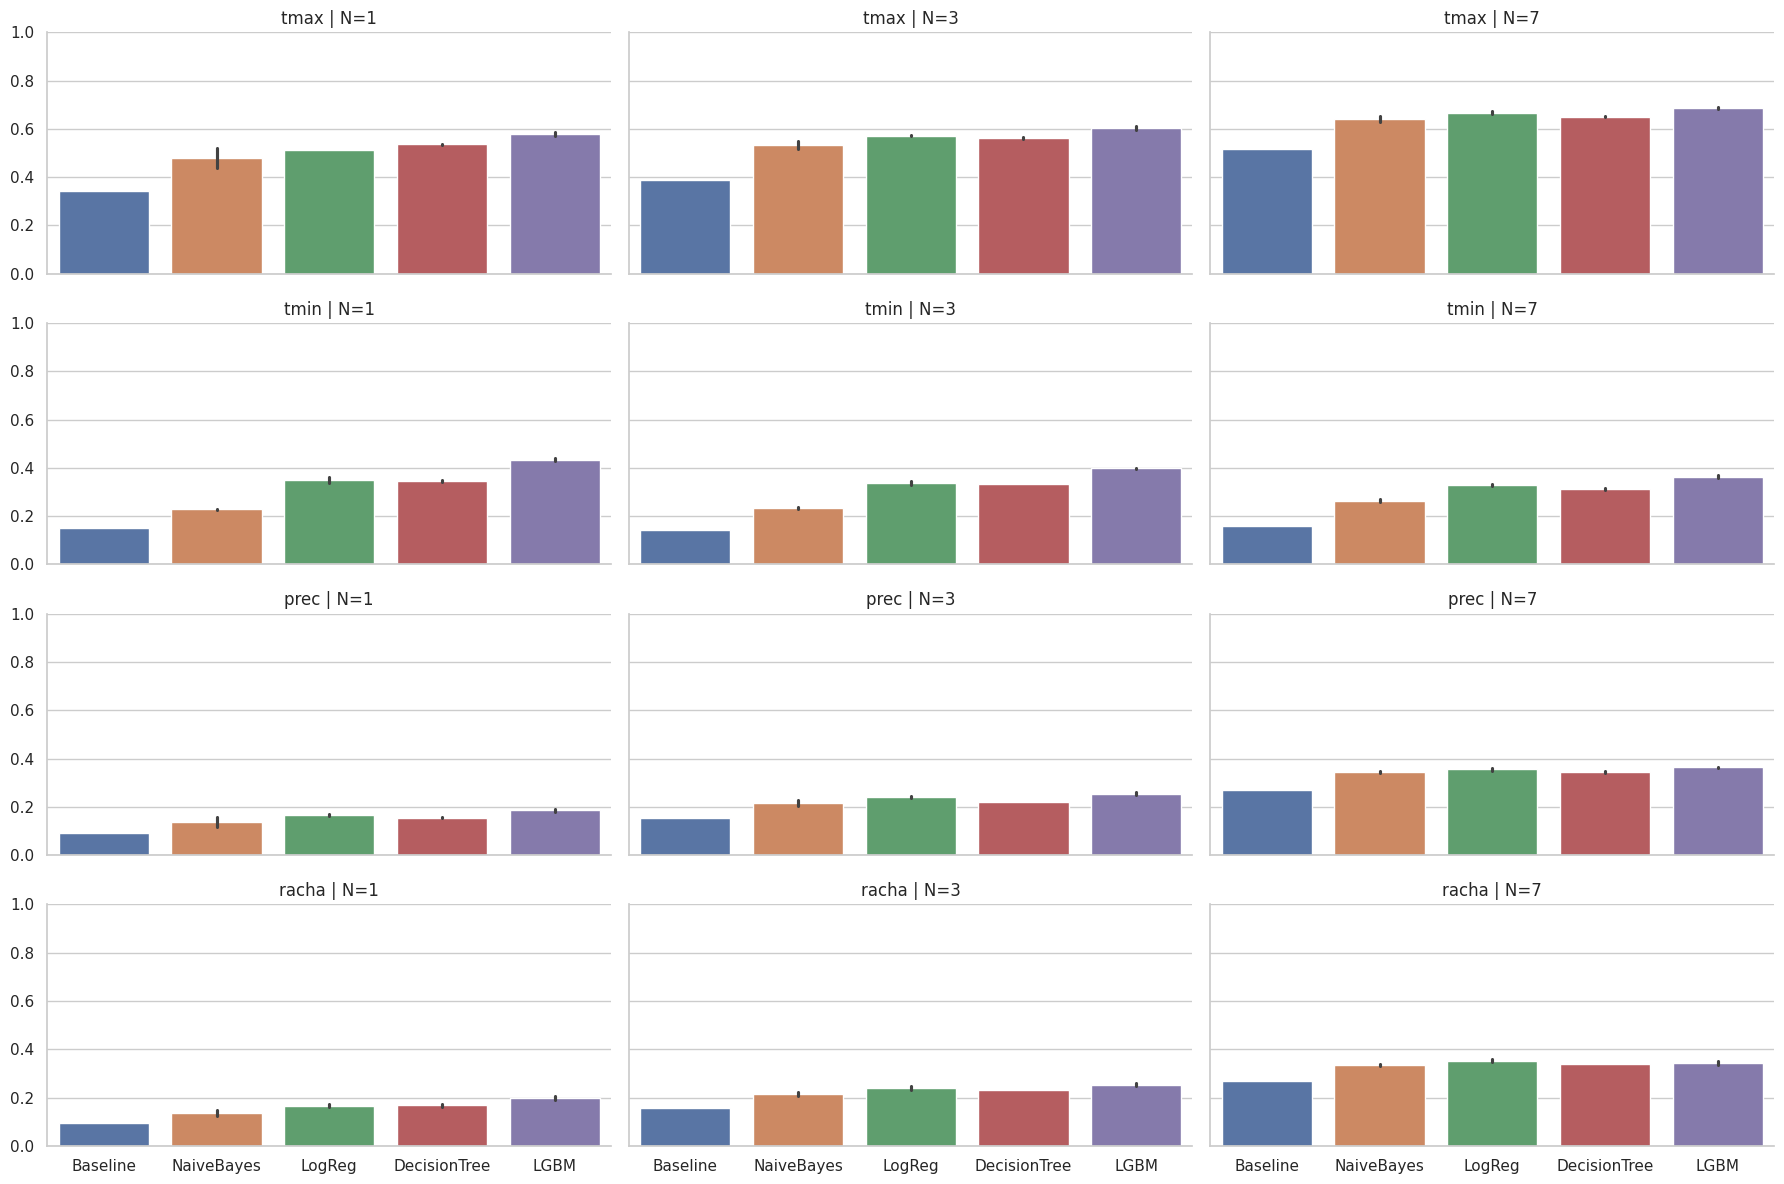

In [19]:
res_spain_combined = pd.concat([res_spain_curated, res_spain_minimal], ignore_index=True)

g = sns.catplot(
    data=res_spain_combined,
    x="model_name",
    y="AP_test",
    col="N",
    row="variable",
    kind="bar",
    hue="model_name",
    height=3,
    aspect=2,
    estimator=lambda x: (x.mean()),
    errorbar=lambda x: (x.min(), x.max())
)

g.set_titles(template="{row_name} | {col_var}={col_name}")
g.set_axis_labels("", "")
g.set(ylim=(0, 1))
g.tight_layout()
plt.show()

## 3.2. CLM

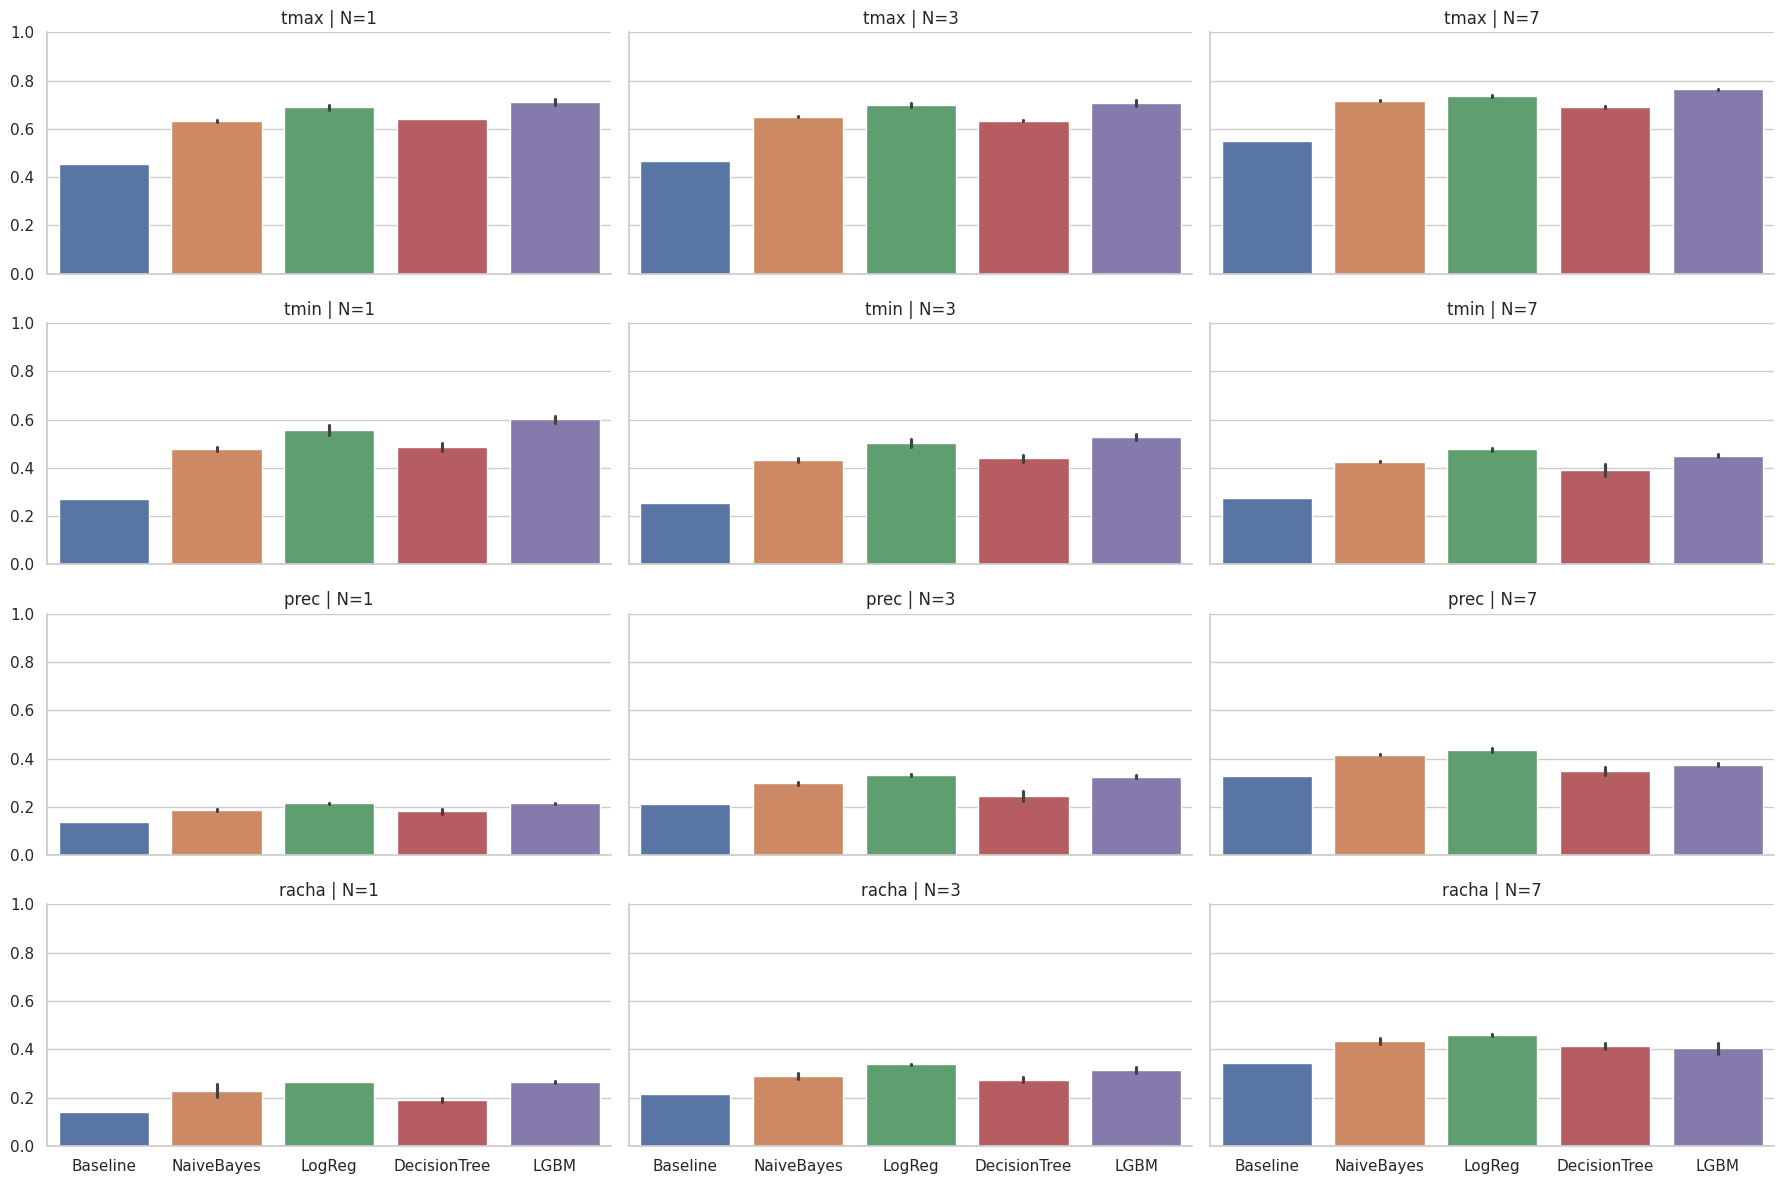

In [20]:
res_clm_combined = pd.concat([res_clm_curated, res_clm_minimal], ignore_index=True)

g = sns.catplot(
    data=res_clm_combined,
    x="model_name",
    y="AP_test",
    col="N",
    row="variable",
    kind="bar",
    hue="model_name",
    height=3,
    aspect=2,
    estimator=lambda x: (x.mean()),
    errorbar=lambda x: (x.min(), x.max())
)

g.set_titles(template="{row_name} | {col_var}={col_name}")
g.set_axis_labels("", "")
g.set(ylim=(0, 1))
g.tight_layout()
plt.show()

# 4. Curvas PR en test

In [21]:
pred_spain_curated[["variable", "N", "model_name", "view", "model_path", "y", "p"]].head()

,variable,N,model_name,view,model_path,y,p
0,tmax,1,Baseline,curated,NaN,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.34975296, 0.03563146, 0.03563146, 0.3497529..."
1,tmax,1,NaiveBayes,curated,data/models/NaiveBayes_tmax_N1_curated_spain.j...,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.99999887, 0.948577, 0.99999815, 1.7811..."
2,tmax,1,LogReg,curated,data/models/LogReg_tmax_N1_curated_spain.joblib,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.97532845, 0.8157898, 0.6476376, 0.8860874, ..."
3,tmax,1,DecisionTree,curated,data/models/DecisionTree_tmax_N1_curated_spain...,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9026907, 0.6539332, 0.0, 0.5387369, 0.00887..."
4,tmax,1,LGBM,curated,data/models/LGBM_tmax_N1_curated_spain.joblib,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8941857, 0.7017802, 0.5669127, 0.65389407, ..."


In [22]:
res_spain_curated[["variable", "N", "model_name", "view", "model_path"]].head()

,variable,N,model_name,view,model_path
0,tmax,1,Baseline,curated,NaN
1,tmax,1,NaiveBayes,curated,data/models/NaiveBayes_tmax_N1_curated_spain.j...
2,tmax,1,LogReg,curated,data/models/LogReg_tmax_N1_curated_spain.joblib
3,tmax,1,DecisionTree,curated,data/models/DecisionTree_tmax_N1_curated_spain...
4,tmax,1,LGBM,curated,data/models/LGBM_tmax_N1_curated_spain.joblib


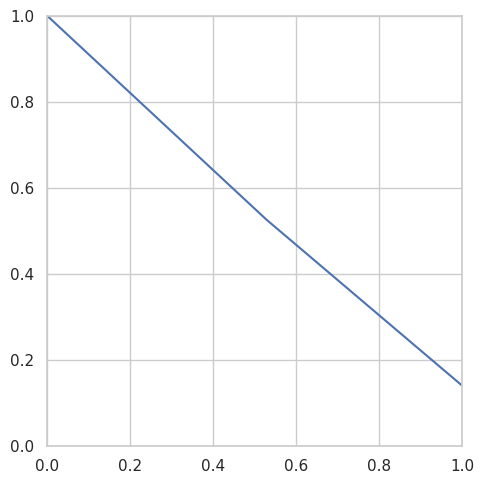

In [23]:
def plot_pr_curve(model_name, y_true, y_score, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    ax.plot(rec, prec, label=f"{model_name}")
    return ax

ax = plot_pr_curve("Baseline", pred_spain_curated.at[0, "y"], pred_spain_curated.at[0, "p"])
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [24]:
df = pred_spain_curated.copy()
df[((df["variable"] == "tmax") & df["N"] == 1 & (df["view"] == "curated"))]

,variable,N,model_name,view,y,p,model_path,threshold,cols
0,tmax,1,Baseline,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.34975296, 0.03563146, 0.03563146, 0.3497529...",NaN,0.04,"[altitud, anio, cos_doy, days_since_prec, days..."
1,tmax,1,NaiveBayes,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.99999887, 0.948577, 0.99999815, 1.7811...",data/models/NaiveBayes_tmax_N1_curated_spain.j...,0.99,"[altitud, anio, cos_doy, days_since_prec, days..."
2,tmax,1,LogReg,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.97532845, 0.8157898, 0.6476376, 0.8860874, ...",data/models/LogReg_tmax_N1_curated_spain.joblib,0.80,"[altitud, anio, cos_doy, days_since_prec, days..."
3,tmax,1,DecisionTree,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9026907, 0.6539332, 0.0, 0.5387369, 0.00887...",data/models/DecisionTree_tmax_N1_curated_spain...,0.82,"[altitud, anio, cos_doy, days_since_prec, days..."
4,tmax,1,LGBM,curated,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8941857, 0.7017802, 0.5669127, 0.65389407, ...",data/models/LGBM_tmax_N1_curated_spain.joblib,0.82,"[altitud, anio, cos_doy, days_since_prec, days..."
5,tmax,3,Baseline,curated,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.45061764, 0.09820807, 0.09820807, 0.4506176...",NaN,0.10,"[altitud, anio, cos_doy, days_since_prec, days..."
6,tmax,3,NaiveBayes,curated,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.9999985, 0.97857296, 0.99999815, 0.003...",data/models/NaiveBayes_tmax_N3_curated_spain.j...,0.99,"[altitud, anio, cos_doy, days_since_prec, days..."
7,tmax,3,LogReg,curated,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9540875, 0.8444013, 0.7188583, 0.82225776, ...",data/models/LogReg_tmax_N3_curated_spain.joblib,0.66,"[altitud, anio, cos_doy, days_since_prec, days..."
8,tmax,3,DecisionTree,curated,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8705578, 0.8490286, 0.45588636, 0.627632, 0...",data/models/DecisionTree_tmax_N3_curated_spain...,0.66,"[altitud, anio, cos_doy, days_since_prec, days..."
9,tmax,3,LGBM,curated,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8868522, 0.729543, 0.6477698, 0.6803264, 0....",data/models/LGBM_tmax_N3_curated_spain.joblib,0.59,"[altitud, anio, cos_doy, days_since_prec, days..."


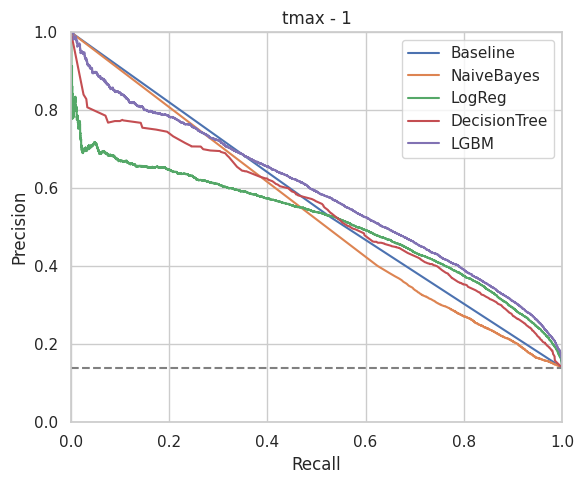

In [25]:
def plot_pr_curves(df, var, N, view, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    idx = ((df["variable"] == var) & (df["N"] == N) & (df["view"] == view))
    for _, row in df.loc[idx].iterrows():
        y_true, y_score = row["y"], row["p"]
        prev = float(y_true.mean())
        ax = plot_pr_curve(row["model_name"], y_true, y_score, ax=ax)
    ax.axhline(prev, ls="--", color="gray")
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{var} - {N}")
    ax.legend(loc="upper right")
    return ax

ax = plot_pr_curves(pred_spain_curated, "tmax", 1, "curated")
plt.tight_layout()
plt.show()

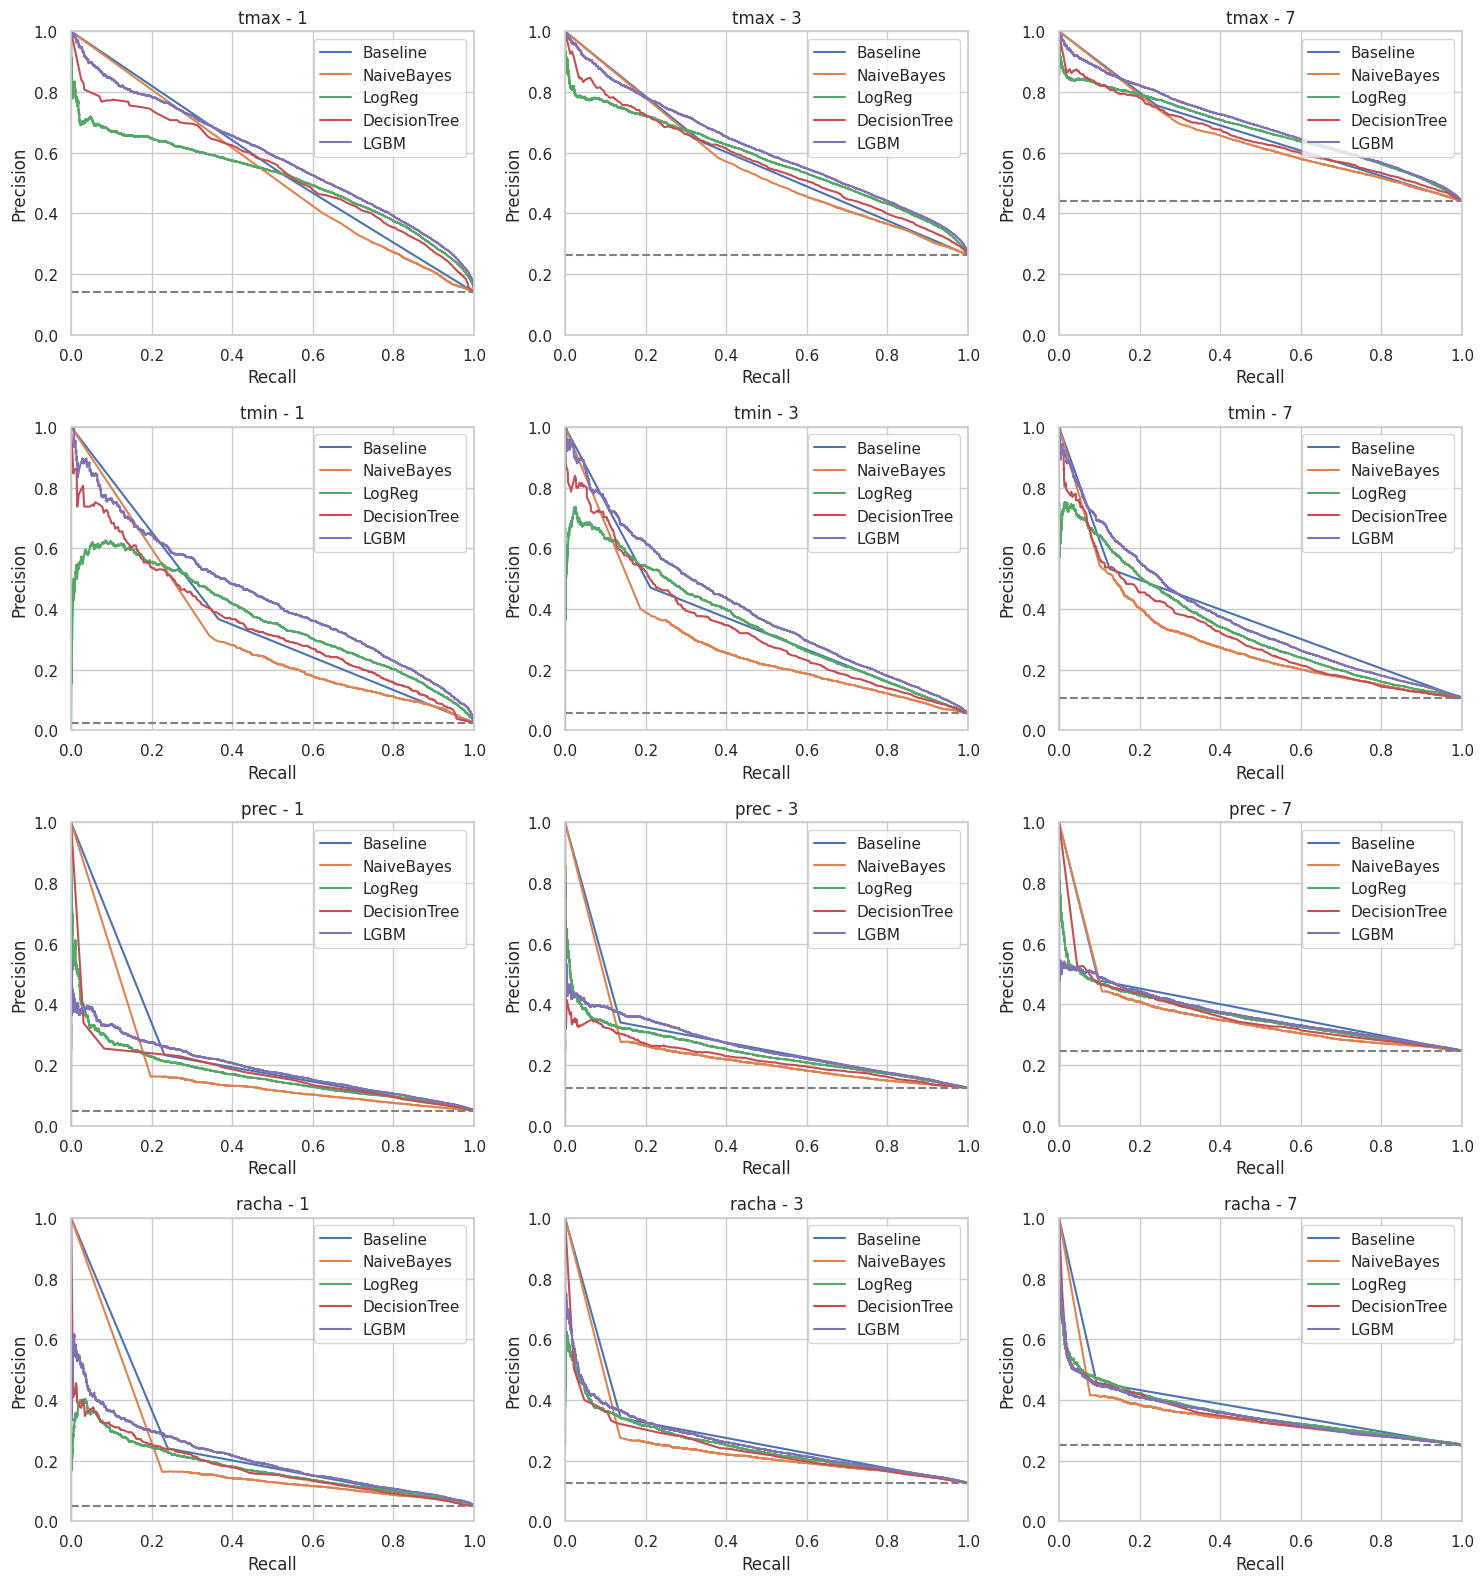

In [26]:
def plot_pr_grid(df, region, view, title=False):
    vars = list(df["variable"].unique())
    Ns = list(df["N"].unique())
    fig, axes = plt.subplots(len(vars), len(Ns), figsize=(5*len(Ns), 4*len(vars)), squeeze=False)
    for i, v in enumerate(vars):
        for j, N in enumerate(Ns):
            plot_pr_curves(df, v, N, view, ax=axes[i][j])
    if title:
        fig.suptitle(f"Curvas PR en test - {region}")
    plt.tight_layout()
    plt.show()

plot_pr_grid(pred_spain_curated, "España", "curated")

# 5. Coeficientes de regresión logística

In [27]:
logreg_full = joblib.load(res_spain_curated.at[2, "model_path"])["model"].named_steps["classifier"]
logreg_min  = joblib.load(res_spain_minimal.at[2, "model_path"])["model"].named_steps["classifier"]

names_full  = logreg_full.feature_names_in_
names_min  = logreg_min.feature_names_in_

coefficients_full   = logreg_full.coef_.flatten()
coefficients_full   = pd.Series(coefficients_full, index=names_full, name="coef_full")
coefficients_min    = logreg_min.coef_.flatten()
coefficients_min    = pd.Series(coefficients_min, index=names_min, name="coef_min")

In [28]:
coefficients_full.abs().sort_values(ascending=False).head(10)

tmax_dist_to_ex    1.997588
tmax               0.974627
tmax_lag_1         0.902364
prec_ewma_3        0.741237
mslp_min_diff_3    0.739761
racha_diff_1       0.677319
tmax_ewma_7        0.674999
tmin_dist_to_ex    0.568984
tmax_ewma_14       0.510069
mslp_max_diff_3    0.490301
Name: coef_full, dtype: float64

In [29]:
coefficients_min.abs().sort_values(ascending=False).head(10)

tmax_dist_to_ex     1.780686
tmax                1.011645
tmin_dist_to_ex     0.602512
koppen_class_Cfb    0.488417
koppen_class_Csa    0.478968
latitud             0.367489
racha_dist_to_ex    0.364992
tmed                0.349707
koppen_main_B       0.328390
altitud             0.324974
Name: coef_min, dtype: float64

In [30]:
coefficients = pd.concat([coefficients_full, coefficients_min], axis=1)
coefficients

,coef_full,coef_min
altitud,-0.268507,-0.324974
latitud,-0.206435,-0.367489
longitud,-0.165184,-0.067426
anio,0.181007,0.204579
cos_doy,0.095762,-0.018545
...,...,...
koppen_class_BWh,-0.008593,-0.069503
koppen_class_Cfa,0.010522,-0.034925
koppen_class_Cfb,0.250512,0.488417
koppen_class_Csa,-0.303426,-0.478968


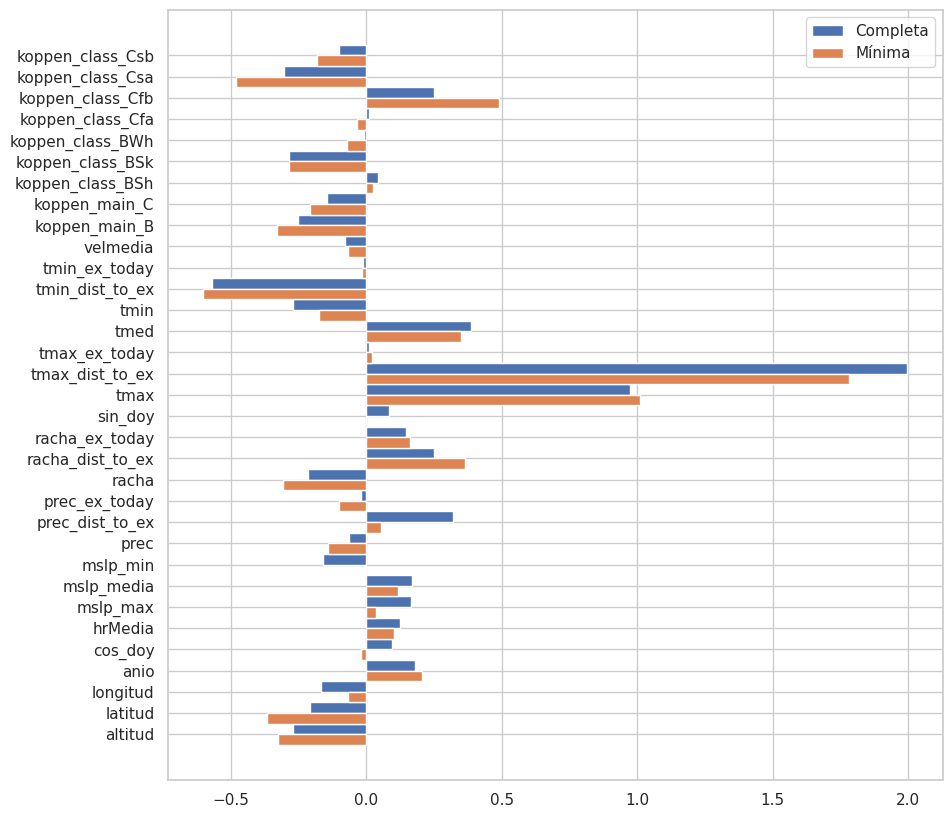

In [31]:
shared = coefficients.copy()
# shared = shared.sort_values("coef_min")
shared = shared[shared["coef_min"].notna()] 
y = np.asarray([i for i, _ in enumerate(shared.index.to_list())])
h = 0.5
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y + h/2, shared["coef_full"], label="Completa", height=h)
ax.barh(y - h/2, shared["coef_min"], label="Mínima", height=h)
ax.set_yticks(y)
ax.set_yticklabels(shared.index)
plt.legend()
plt.show()

# 6. Importancia de características en LGBM

In [32]:
res_spain_curated.head()

,variable,N,model_name,view,n_features,prevalence_train,prevalence_val,prevalence_test,AP_train,ROC_AUC_train,AP_val,ROC_AUC_val,AP_test,ROC_AUC_test,precision_train,recall_train,accuracy_train,f1_train,precision_val,recall_val,accuracy_val,f1_val,precision_test,recall_test,accuracy_test,f1_test,best_params,model_path,s
0,tmax,1,Baseline,curated,100,0.051941,0.081151,0.140343,0.156062,0.657004,0.230611,0.688969,0.344218,0.725325,0.349753,0.349619,0.932457,0.349686,0.430386,0.427962,0.907614,0.429171,0.526259,0.528289,0.867056,0.527272,{},NaN,1.3
1,tmax,1,NaiveBayes,curated,100,0.051941,0.081151,0.140343,0.241951,0.801064,0.302977,0.785996,0.437135,0.805849,0.110442,0.786754,0.659776,0.193693,0.146851,0.808808,0.603164,0.248570,0.230109,0.864194,0.575155,0.363443,"{""classifier__var_smoothing"": 2.91520363852882...",data/models/NaiveBayes_tmax_N1_curated_spain.j...,18.3
2,tmax,1,LogReg,curated,100,0.051941,0.081151,0.140343,0.301601,0.875603,0.379455,0.867673,0.511891,0.868497,0.325116,0.465209,0.922063,0.382746,0.375245,0.554797,0.888912,0.447689,0.454194,0.673788,0.840584,0.542616,"{""classifier__C"": 0.005611516415334507}",data/models/LogReg_tmax_N1_curated_spain.joblib,165.6
3,tmax,1,DecisionTree,curated,100,0.051941,0.081151,0.140343,0.370364,0.894718,0.401084,0.858513,0.538835,0.859565,0.357253,0.489990,0.927721,0.413224,0.399563,0.499488,0.898471,0.443972,0.462757,0.618200,0.845693,0.529302,"{""classifier__min_samples_leaf"": 100, ""classif...",data/models/DecisionTree_tmax_N1_curated_spain...,342.6
4,tmax,1,LGBM,curated,100,0.051941,0.081151,0.140343,0.412743,0.920474,0.449316,0.886906,0.586436,0.882884,0.385864,0.498809,0.932732,0.435127,0.439396,0.521680,0.907170,0.477016,0.509209,0.626212,0.862836,0.561682,"{""classifier__num_leaves"": 64, ""classifier__le...",data/models/LGBM_tmax_N1_curated_spain.joblib,1079.9


In [33]:
lgbm_full = joblib.load(res_spain_curated.at[4, "model_path"])["model"].named_steps["classifier"]
lgbm_min  = joblib.load(res_spain_minimal.at[4, "model_path"])["model"].named_steps["classifier"]

names_full  = lgbm_full.feature_names_in_
names_min  = lgbm_min.feature_names_in_

gain_full   = lgbm_full.booster_.feature_importance(importance_type='gain')
gain_full   = pd.Series(gain_full, index=names_full, name="gain_full")
gain_min    = lgbm_min.booster_.feature_importance(importance_type='gain')
gain_min    = pd.Series(gain_min, index=names_min, name="gain_min")

In [34]:
gains = pd.concat([gain_full, gain_min], axis=1)
gains

,gain_full,gain_min
altitud,397618.278198,356922.376015
anio,313361.763294,368706.618469
cos_doy,401487.688786,591855.818432
days_since_prec,258671.100166,NaN
days_since_prec_ex,67490.151459,NaN
...,...,...
tmin_roll_3_max,46791.347572,NaN
tmin_roll_3_mean,67672.068672,NaN
tmin_roll_7_max,46802.469009,NaN
tmin_roll_7_mean,52889.153988,NaN


In [35]:
gains.sort_values("gain_full", ascending=False)

,gain_full,gain_min
tmax,1.018668e+07,6.908449e+06
tmax_dist_to_ex,4.776569e+06,3.468247e+06
tmed,2.973481e+06,2.675661e+06
days_since_tmax_ex,8.108399e+05,NaN
mslp_min_diff_1,5.359920e+05,NaN
...,...,...
extreme_tmin_lag_1,1.044263e+03,NaN
extreme_racha_lag_1,9.414179e+02,NaN
racha_ex_today,4.444930e+02,1.371547e+03
extreme_prec_lag_1,3.979265e+02,NaN


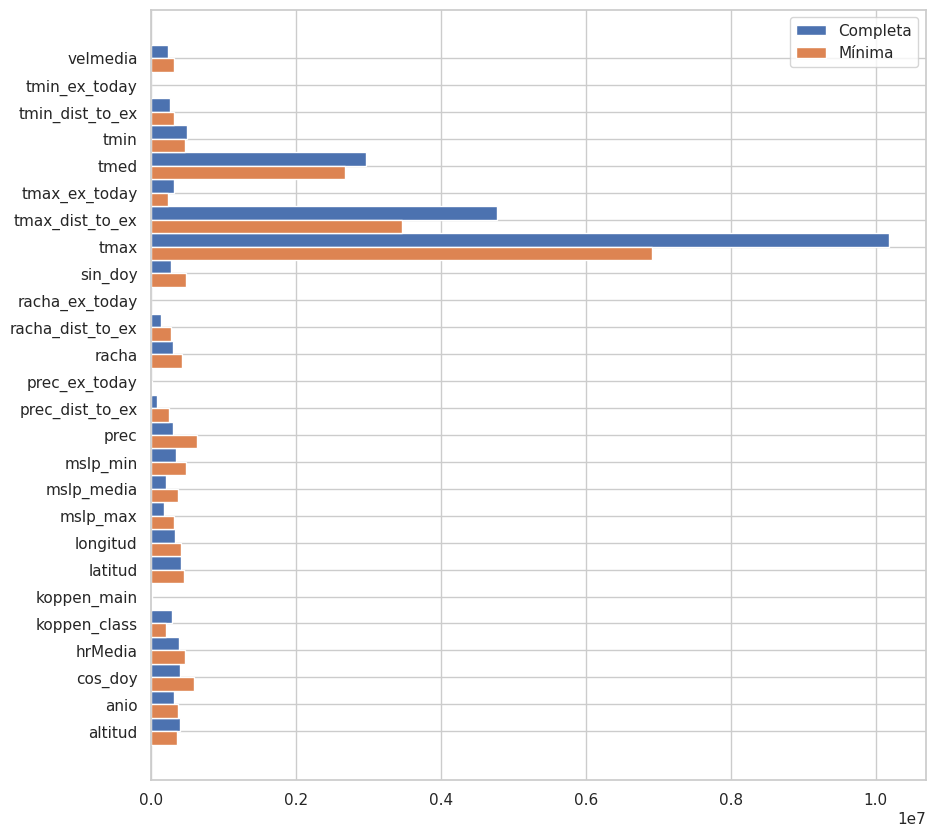

In [36]:
shared = gains.copy()
# shared = shared.sort_values("gain_min")
shared = shared[shared["gain_min"].notna()] 
y = np.asarray([i for i, _ in enumerate(shared.index.to_list())])
h = 0.5
fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y + h/2, shared["gain_full"], label="Completa", height=h)
ax.barh(y - h/2, shared["gain_min"], label="Mínima", height=h)
ax.set_yticks(y)
ax.set_yticklabels(shared.index)
plt.legend()
plt.show()

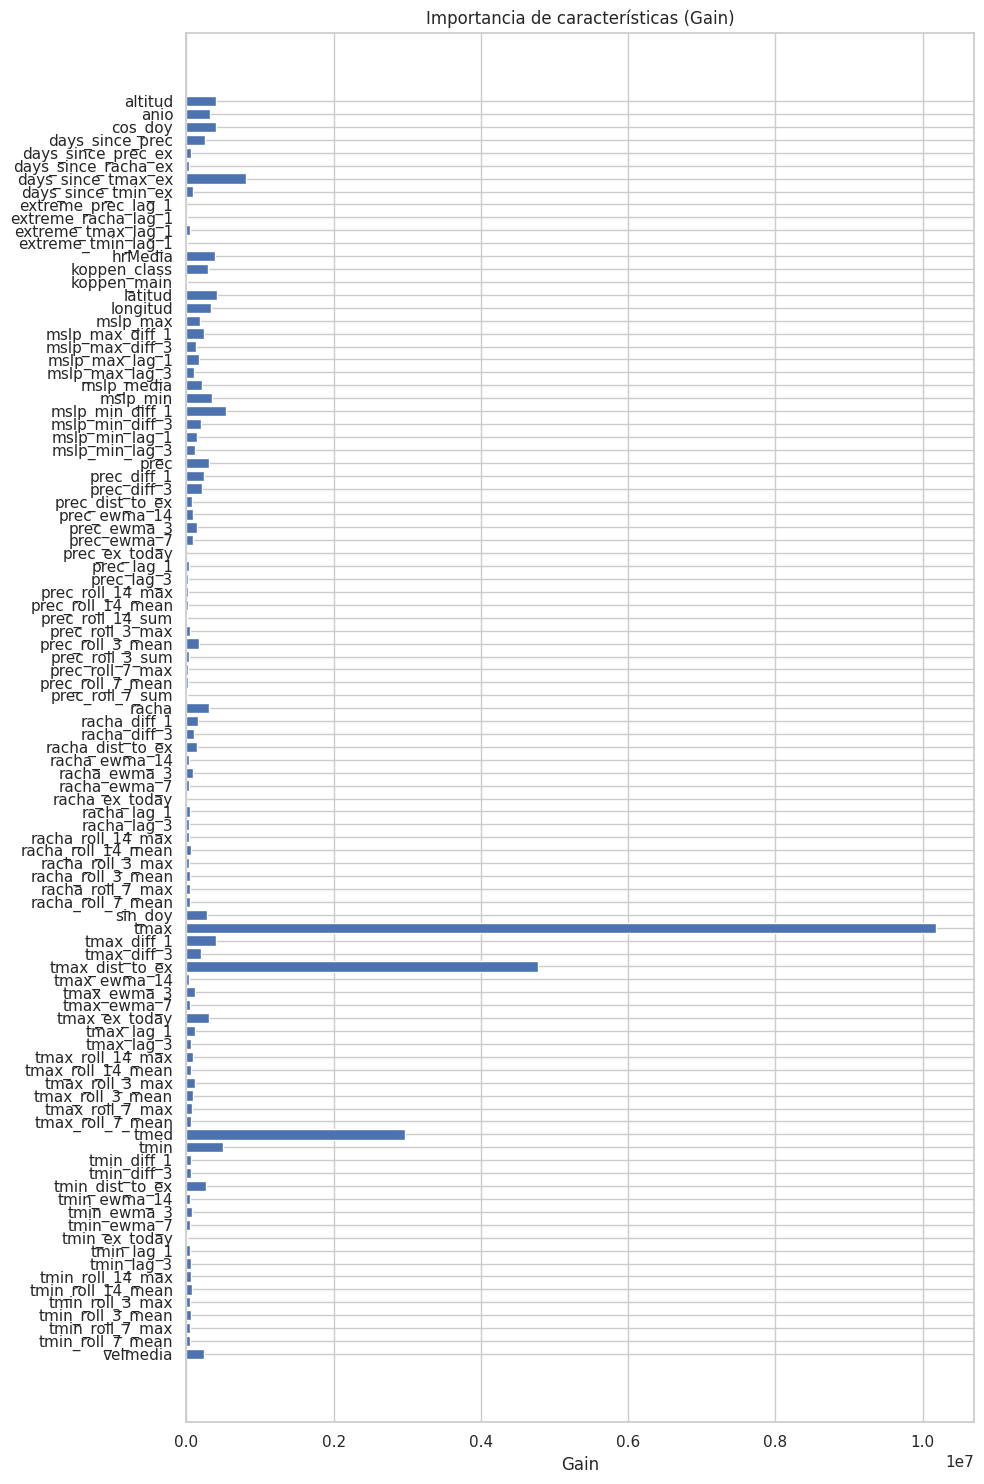

In [37]:
fig, ax = plt.subplots(figsize=(10, 15))

ax.barh(gain_full.index, gain_full.values)
ax.invert_yaxis()

plt.title("Importancia de características (Gain)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()